Game-Level Hybrid Integration Model:

This notebook extends the earlier review-level hybrid analysis into a game-level setting. Instead of treating each row as a review, I aggregate the review-level behavioral and text-derived information so that each row represents one game.

The goal here is to test whether combining aggregated behavioral and text features improves the prediction of game-level recommendation quality compared with using either branch alone.

 Main goals:
- Load the behavioral and text branch outputs
- Merge both datasets at review level
- Aggregate the merged data to one row per game
- Optionally include game-cluster information
- Build behavioral-only, text-only, and hybrid feature sets
- Train multiple classifiers and compare their performance
- Interpret which aggregated game-level features matter most

In [1]:
# Imports
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

 Load the Behavioral and Text Branch Outputs:

I begin by loading the same two final branch outputs used in the review-level hybrid notebook:

- `steam_reviews_sampled.parquet` from the behavioral branch
- `steam_text_features_export.parquet` from the text mining branch

Although the final model in this notebook will be game-level, I still need to begin from review-level data so I can aggregate it properly afterward.

In [2]:

BASE = r'C:\Users\Fareed Durgam\Downloads\\'

behavior_path = BASE + 'steam_reviews_sampled.parquet'
text_path = BASE + 'steam_text_features_export.parquet'

print("Behavioral exists:", os.path.exists(behavior_path))
print("Text exists      :", os.path.exists(text_path))

print("\nLoading behavioral data...")
df_behavioral = pd.read_parquet(behavior_path)
print(f"Behavioral : {len(df_behavioral):,} rows, {df_behavioral.shape[1]} columns")

print("\nLoading text features...")
df_text = pd.read_parquet(text_path)
print(f"Text       : {len(df_text):,} rows, {df_text.shape[1]} columns")

print("\nBoth files loaded successfully")

Behavioral exists: True
Text exists      : True

Loading behavioral data...
Behavioral : 2,609,677 rows, 23 columns

Loading text features...
Text       : 919,083 rows, 15 columns

Both files loaded successfully


Inspect the Structure of Both Datasets:

Before merging, I inspect the columns and data types of both datasets. This helps confirm that the expected review-level identifiers and engineered text features are available and that the two branch outputs are aligned structurally.

In [3]:
print("=" * 60)
print("BEHAVIORAL FILE")
print("=" * 60)
print("Shape:", df_behavioral.shape)
print("Columns:", df_behavioral.columns.tolist())

print("\n" + "=" * 60)
print("TEXT FEATURES FILE")
print("=" * 60)
print("Shape:", df_text.shape)
print("Columns:", df_text.columns.tolist())

BEHAVIORAL FILE
Shape: (2609677, 23)
Columns: ['Unnamed: 0', 'app_id', 'app_name', 'review_id', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author.steamid', 'author.num_games_owned', 'author.num_reviews', 'author.playtime_forever', 'author.playtime_last_two_weeks', 'author.playtime_at_review', 'author.last_played']

TEXT FEATURES FILE
Shape: (919083, 15)
Columns: ['review_id', 'app_id', 'app_name', 'review_cleaned_sentiment', 'polarity', 'subjectivity', 'word_count_cleaned', 'ttr', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label', 'is_helpful', 'votes_helpful', 'recommended']


 Validate the Review-Level Merge Key:

Even though the final model is game-level, the two branch outputs must still be merged first at review level. Because of that, I verify that `review_id` exists in both datasets and that the overlap between the two branches is sufficient for a valid join.

In [4]:
print("review_id in behavioral:", 'review_id' in df_behavioral.columns)
print("review_id in text      :", 'review_id' in df_text.columns)

print("\nBehavioral unique review_ids:", df_behavioral['review_id'].nunique())
print("Text unique review_ids      :", df_text['review_id'].nunique())

common_reviews = set(df_behavioral['review_id'].unique()) & set(df_text['review_id'].unique())
print("Common review_ids           :", len(common_reviews))

review_id in behavioral: True
review_id in text      : True

Behavioral unique review_ids: 2607599
Text unique review_ids      : 918399
Common review_ids           : 918399


 Build the Review-Level Hybrid Base Table:

Before aggregating to game level, I first create a clean review-level hybrid dataset. This means:
- selecting the useful behavioral columns
- removing duplicated fields from the text side
- merging the two branches on `review_id`

This merged review-level table becomes the base from which all game-level aggregates are constructed.

In [5]:
# Keep needed behavioral columns
behavior_cols = [
    'review_id',
    'app_id',
    'app_name',
    'recommended',
    'votes_helpful',
    'steam_purchase',
    'received_for_free',
    'written_during_early_access',
    'author.num_games_owned',
    'author.num_reviews',
    'author.playtime_at_review'
]

behavior_cols = [c for c in behavior_cols if c in df_behavioral.columns]
df_behavioral_sub = df_behavioral[behavior_cols].copy()

# Drop duplicated columns from text before merge
drop_from_text = ['app_id', 'app_name', 'recommended', 'votes_helpful']
drop_from_text = [c for c in drop_from_text if c in df_text.columns]
df_text_sub = df_text.drop(columns=drop_from_text).copy()

# Merge review-level hybrid table
df_hybrid_review = df_behavioral_sub.merge(
    df_text_sub,
    on='review_id',
    how='inner'
)

print("Hybrid review-level shape:", df_hybrid_review.shape)
print("Unique review_ids:", df_hybrid_review['review_id'].nunique())
display(df_hybrid_review.head())

Hybrid review-level shape: (920451, 21)
Unique review_ids: 918399


,review_id,app_id,app_name,recommended,votes_helpful,steam_purchase,received_for_free,written_during_early_access,author.num_games_owned,author.num_reviews,author.playtime_at_review,review_cleaned_sentiment,polarity,subjectivity,word_count_cleaned,ttr,lda_topic,lda_topic_label,nmf_topic,nmf_topic_label,is_helpful
0,76039982,70,Half-Life,True,0,True,False,False,23,3,2883.0,tower ridicoulous tie,0.000000,0.000000,3,1.000000,6,"Strategy, War & Modding Community",0,First Impressions & Game World,0
1,54706129,70,Half-Life,True,1,True,False,False,208,33,108.0,try new,0.068182,0.227273,2,1.000000,1,Game Updates & Value Assessment,0,First Impressions & Game World,1
2,62350493,70,Half-Life,True,0,False,True,False,24,5,209.0,ultimate fps ever hand,-0.097222,0.644444,4,1.000000,8,FPS & Casual Gaming,1,Top Rated RPG & Strategy Games,0
3,78781414,70,Half-Life,True,0,True,False,False,18,12,877.0,old issa fun liek,0.200000,0.200000,3,1.000000,7,Nostalgia & Series Comparisons,12,Game Longevity & Long-term Play,0
4,72234963,70,Half-Life,True,0,True,False,False,73,12,406.0,remade reimagined fps genre doom quake immersi...,0.056210,0.508889,53,0.867925,4,Core Game Quality & Experience,5,"Story, Gameplay & Soundtrack Quality",0


Clean Behavioral Variables and Engineer Playtime Features

Before aggregating to game level, I apply a small behavioral cleaning step to the merged review-level table. This follows the same logic as the earlier behavioral and review-level hybrid notebooks.

In particular, I:
- remove obviously unrealistic outliers in reviewer game ownership
- drop rows missing key behavioral fields
- create playtime in hours
- create a log-transformed playtime feature

In [6]:
# Remove unrealistic outliers
if 'author.num_games_owned' in df_hybrid_review.columns:
    print("Rows with author.num_games_owned > 25000:",
          (df_hybrid_review['author.num_games_owned'] > 25000).sum())
    df_hybrid_review = df_hybrid_review[df_hybrid_review['author.num_games_owned'] <= 25000].copy()

# Drop rows missing important behavioral fields
required_behavior_cols = [
    'author.playtime_at_review',
    'author.num_games_owned',
    'author.num_reviews'
]
required_behavior_cols = [c for c in required_behavior_cols if c in df_hybrid_review.columns]
df_hybrid_review = df_hybrid_review.dropna(subset=required_behavior_cols).copy()

# Playtime features
df_hybrid_review['playtime_hours'] = df_hybrid_review['author.playtime_at_review'] / 60
df_hybrid_review['log_playtime_hours'] = np.log1p(df_hybrid_review['playtime_hours'])

print("Shape after cleaning:", df_hybrid_review.shape)
display(df_hybrid_review[['author.num_games_owned', 'author.num_reviews', 'playtime_hours']].describe())

Rows with author.num_games_owned > 25000: 1
Shape after cleaning: (919210, 23)


,author.num_games_owned,author.num_reviews,playtime_hours
count,919210.000000,919210.000000,919210.000000
mean,183.649063,12.728206,150.570403
std,334.578166,35.427984,439.235502
min,0.000000,1.000000,0.016667
25%,38.000000,2.000000,9.900000
50%,97.000000,5.000000,32.233333
75%,213.000000,12.000000,114.100000
max,22019.000000,3473.000000,34530.133333


 Aggregate the Review-Level Data to Game Level

Now I convert the review-level hybrid table into a game-level table. This means grouping by `app_id` and `app_name` and computing aggregated summaries for each game.

The resulting table will contain one row per game and will include:
- aggregated behavioral variables
- aggregated text variables
- a game-level recommendation rate
- topic-distribution features

This is the core transformation that changes the problem from review-level classification to game-level classification.

In [7]:
# Base aggregated game table
df_game = df_hybrid_review.groupby(['app_id', 'app_name']).agg(
    game_recommendation_rate=('recommended', 'mean'),
    review_count=('review_id', 'count'),

    steam_purchase_rate=('steam_purchase', 'mean'),
    received_for_free_rate=('received_for_free', 'mean'),
    early_access_rate=('written_during_early_access', 'mean'),

    mean_num_games_owned=('author.num_games_owned', 'mean'),
    median_num_games_owned=('author.num_games_owned', 'median'),

    mean_author_num_reviews=('author.num_reviews', 'mean'),
    median_author_num_reviews=('author.num_reviews', 'median'),

    mean_playtime_hours=('playtime_hours', 'mean'),
    median_playtime_hours=('playtime_hours', 'median'),
    mean_log_playtime_hours=('log_playtime_hours', 'mean'),

    mean_votes_helpful=('votes_helpful', 'mean'),
    median_votes_helpful=('votes_helpful', 'median'),
    helpful_review_rate=('is_helpful', 'mean'),

    mean_polarity=('polarity', 'mean'),
    mean_subjectivity=('subjectivity', 'mean'),
    mean_word_count=('word_count_cleaned', 'mean'),
    mean_ttr=('ttr', 'mean')
).reset_index()

print("Base game-level table shape:", df_game.shape)
display(df_game.head())

Base game-level table shape: (315, 21)


,app_id,app_name,game_recommendation_rate,review_count,steam_purchase_rate,received_for_free_rate,early_access_rate,mean_num_games_owned,median_num_games_owned,mean_author_num_reviews,median_author_num_reviews,mean_playtime_hours,median_playtime_hours,mean_log_playtime_hours,mean_votes_helpful,median_votes_helpful,helpful_review_rate,mean_polarity,mean_subjectivity,mean_word_count,mean_ttr
0,70,Half-Life,0.960970,2639,0.766957,0.046230,0.0,188.336112,94.0,23.747632,10.0,25.371031,10.450000,2.345863,1.551345,0.0,0.278136,0.133017,0.435255,16.701402,0.960396
1,240,Counter-Strike: Source,0.949770,3703,0.626519,0.030786,0.0,164.806643,81.0,18.387254,6.0,330.534954,29.933333,3.699962,2.694032,0.0,0.320551,0.172132,0.437733,8.899271,0.967503
2,420,Half-Life 2: Episode Two,0.956124,1094,0.717550,0.025594,0.0,236.969835,135.0,34.473492,15.0,12.007191,6.400000,2.100182,1.806216,0.0,0.301645,0.089612,0.419474,14.078611,0.955400
3,620,Portal 2,0.987010,10162,0.753001,0.021059,0.0,169.073608,86.0,14.849045,6.0,35.062184,14.233333,2.802461,0.756052,0.0,0.209998,0.200827,0.483341,11.574592,0.958201
4,2870,X Rebirth,0.393443,488,0.782787,0.002049,0.0,341.608607,232.0,17.514344,8.0,60.622268,17.091667,2.905560,9.852459,4.0,0.854508,-0.043556,0.508807,49.774590,0.917156


 Add Topic Distribution Features:

The topic assignments from the text-mining branch are review-level variables. To use them at game level, I convert them into proportions, meaning the share of reviews from each game that belong to each topic.

This allows the final game-level model to capture thematic differences between games without rerunning the topic models.

In [8]:
# LDA topic proportions
lda_props = pd.crosstab(
    df_hybrid_review['app_id'],
    df_hybrid_review['lda_topic'],
    normalize='index'
)
lda_props.columns = [f'lda_topic_prop_{col}' for col in lda_props.columns]
lda_props = lda_props.reset_index()

# NMF topic proportions
nmf_props = pd.crosstab(
    df_hybrid_review['app_id'],
    df_hybrid_review['nmf_topic'],
    normalize='index'
)
nmf_props.columns = [f'nmf_topic_prop_{col}' for col in nmf_props.columns]
nmf_props = nmf_props.reset_index()

# Merge topic proportions into game-level table
df_game = df_game.merge(lda_props, on='app_id', how='left')
df_game = df_game.merge(nmf_props, on='app_id', how='left')

print("Game-level table after topic proportions:", df_game.shape)
display(df_game.head())

Game-level table after topic proportions: (315, 46)


,app_id,app_name,game_recommendation_rate,review_count,steam_purchase_rate,received_for_free_rate,early_access_rate,mean_num_games_owned,median_num_games_owned,mean_author_num_reviews,median_author_num_reviews,mean_playtime_hours,median_playtime_hours,mean_log_playtime_hours,mean_votes_helpful,median_votes_helpful,helpful_review_rate,mean_polarity,mean_subjectivity,mean_word_count,mean_ttr,lda_topic_prop_0,lda_topic_prop_1,lda_topic_prop_2,lda_topic_prop_3,lda_topic_prop_4,lda_topic_prop_5,lda_topic_prop_6,lda_topic_prop_7,lda_topic_prop_8,lda_topic_prop_9,nmf_topic_prop_0,nmf_topic_prop_1,nmf_topic_prop_2,nmf_topic_prop_3,nmf_topic_prop_4,nmf_topic_prop_5,nmf_topic_prop_6,nmf_topic_prop_7,nmf_topic_prop_8,nmf_topic_prop_9,nmf_topic_prop_10,nmf_topic_prop_11,nmf_topic_prop_12,nmf_topic_prop_13,nmf_topic_prop_14
0,70,Half-Life,0.960970,2639,0.766957,0.046230,0.0,188.336112,94.0,23.747632,10.0,25.371031,10.450000,2.345863,1.551345,0.0,0.278136,0.133017,0.435255,16.701402,0.960396,0.084123,0.104206,0.170519,0.068208,0.227738,0.048124,0.036377,0.133763,0.084502,0.042440,0.375142,0.054566,0.004547,0.038272,0.031451,0.053050,0.023873,0.021978,0.025388,0.022357,0.059871,0.021978,0.115195,0.012884,0.139447
1,240,Counter-Strike: Source,0.949770,3703,0.626519,0.030786,0.0,164.806643,81.0,18.387254,6.0,330.534954,29.933333,3.699962,2.694032,0.0,0.320551,0.172132,0.437733,8.899271,0.967503,0.123683,0.153389,0.111801,0.051850,0.086416,0.082906,0.086146,0.165001,0.085336,0.053470,0.430462,0.052660,0.017553,0.061842,0.032946,0.003781,0.021334,0.091007,0.016473,0.060491,0.040238,0.022684,0.079665,0.016473,0.052390
2,420,Half-Life 2: Episode Two,0.956124,1094,0.717550,0.025594,0.0,236.969835,135.0,34.473492,15.0,12.007191,6.400000,2.100182,1.806216,0.0,0.301645,0.089612,0.419474,14.078611,0.955400,0.056673,0.122486,0.159049,0.053931,0.298903,0.032907,0.022852,0.153565,0.058501,0.041133,0.365631,0.020110,0.001828,0.031079,0.008227,0.085923,0.019196,0.031079,0.010055,0.009141,0.018282,0.053016,0.067642,0.017367,0.261426
3,620,Portal 2,0.987010,10162,0.753001,0.021059,0.0,169.073608,86.0,14.849045,6.0,35.062184,14.233333,2.802461,0.756052,0.0,0.209998,0.200827,0.483341,11.574592,0.958201,0.088172,0.087876,0.196713,0.078429,0.292757,0.057469,0.041527,0.053139,0.051565,0.052352,0.401988,0.071443,0.054320,0.049203,0.039854,0.120252,0.031096,0.030014,0.020862,0.010923,0.041330,0.031293,0.030112,0.012104,0.055206
4,2870,X Rebirth,0.393443,488,0.782787,0.002049,0.0,341.608607,232.0,17.514344,8.0,60.622268,17.091667,2.905560,9.852459,4.0,0.854508,-0.043556,0.508807,49.774590,0.917156,0.022541,0.403689,0.418033,0.020492,0.045082,0.012295,0.008197,0.010246,0.036885,0.022541,0.391393,0.022541,0.002049,0.094262,0.081967,0.010246,0.049180,0.045082,0.026639,0.034836,0.026639,0.051230,0.102459,0.047131,0.014344


 Optionally Merge Game Cluster Information:

 Unlike the review-level hybrid model, game-level clustering aligns naturally here because both are defined at one row per game.

This step is optional and only runs if a cluster file is available.

In [9]:
USE_CLUSTER_FEATURE = True
cluster_path = r'C:\Users\Fareed Durgam\Downloads\game_cluster_output.parquet'

if USE_CLUSTER_FEATURE and os.path.exists(cluster_path):
    df_cluster = pd.read_parquet(cluster_path)

    cluster_cols = [c for c in ['app_id', 'cluster_label'] if c in df_cluster.columns]
    df_cluster = df_cluster[cluster_cols].copy()

    df_game = df_game.merge(df_cluster, on='app_id', how='left')
    print("Cluster file merged")
    print(df_cluster.shape)
    print(df_cluster.head())
else:
    print("Cluster feature skipped")

Cluster file merged
(315, 2)
   app_id  cluster_label
0      70              1
1     240              1
2     420              1
3     620              1
4    2870              0


Visualize the Exported Game Clusters:

This PCA plot shows the exported game clusters included in the game-level hybrid dataset. Although some overlap is visible between clusters, there is still meaningful structure in the reduced 2D space, with certain clusters occupying different regions more strongly than others.

This is expected because PCA is only a two-dimensional projection of the original higher-dimensional clustering space. The plot is therefore used as a visual link between the earlier unsupervised clustering notebook and the current game-level hybrid notebook, where cluster membership is included as an additional game-level feature.

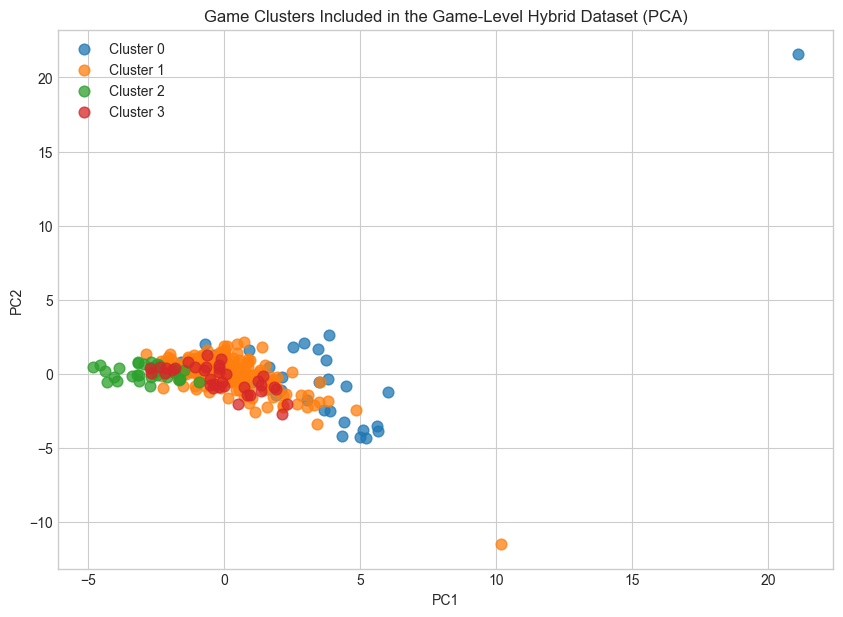

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Only run if cluster labels are present
if 'cluster_label' in df_game.columns:

    # Select numeric game-level features for visualization
    cluster_plot_features = [
        'review_count',
        'steam_purchase_rate',
        'received_for_free_rate',
        'early_access_rate',
        'mean_num_games_owned',
        'median_num_games_owned',
        'mean_author_num_reviews',
        'median_author_num_reviews',
        'mean_playtime_hours',
        'median_playtime_hours',
        'mean_log_playtime_hours',
        'mean_votes_helpful',
        'median_votes_helpful',
        'helpful_review_rate',
        'mean_polarity',
        'mean_subjectivity',
        'mean_word_count',
        'mean_ttr'
    ]

    cluster_plot_features = [c for c in cluster_plot_features if c in df_game.columns]

    X_plot = df_game[cluster_plot_features].fillna(0).copy()

    scaler_plot = StandardScaler()
    X_plot_scaled = scaler_plot.fit_transform(X_plot)

    pca = PCA(n_components=2, random_state=42)
    reduced = pca.fit_transform(X_plot_scaled)

    plt.figure(figsize=(10, 7))

    for c in sorted(df_game['cluster_label'].dropna().unique()):
        mask = df_game['cluster_label'] == c
        plt.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            label=f'Cluster {c}',
            alpha=0.75,
            s=60
        )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Game Clusters Included in the Game-Level Hybrid Dataset (PCA)')
    plt.legend()
    plt.show()

else:
    print("cluster_label not found in df_game")

 Define the Game-Level Target:

At game level, the original review-level target recommended no longer applies directly because each row now represents one game rather than one review.

To create a balanced game-level classification task, I define:
- high_recommendation_game = 1 if a game’s recommendation rate is above or equal to the median
- high_recommendation_game = 0 otherwise

Using the median creates a more balanced binary target than using a fixed threshold.

In [10]:
median_rate = df_game['game_recommendation_rate'].median()
df_game['high_recommendation_game'] = (df_game['game_recommendation_rate'] >= median_rate).astype(int)

print("Median recommendation rate:", round(median_rate, 4))
print(df_game['high_recommendation_game'].value_counts())
print(df_game['high_recommendation_game'].value_counts(normalize=True).round(4))

Median recommendation rate: 0.8927
high_recommendation_game
1    158
0    157
Name: count, dtype: int64
high_recommendation_game
1    0.5016
0    0.4984
Name: proportion, dtype: float64


Define Behavioral, Text, and Hybrid Feature Groups:

Next, I explicitly separate the aggregated game-level features into:
- behavioral features
- text features
- optional cluster features

This allows me to build three comparable model inputs:
- behavioral-only
- text-only
- combined hybrid

In [11]:
behavioral_features = [
    'review_count',
    'steam_purchase_rate',
    'received_for_free_rate',
    'early_access_rate',
    'mean_num_games_owned',
    'median_num_games_owned',
    'mean_author_num_reviews',
    'median_author_num_reviews',
    'mean_playtime_hours',
    'median_playtime_hours',
    'mean_log_playtime_hours',
    'mean_votes_helpful',
    'median_votes_helpful',
    'helpful_review_rate'
]
behavioral_features = [c for c in behavioral_features if c in df_game.columns]

text_features = [
    'mean_polarity',
    'mean_subjectivity',
    'mean_word_count',
    'mean_ttr'
]
text_features = [c for c in text_features if c in df_game.columns]

topic_features = [c for c in df_game.columns if c.startswith('lda_topic_prop_') or c.startswith('nmf_topic_prop_')]

cluster_features = []
if 'cluster_label' in df_game.columns:
    df_game['cluster_label'] = df_game['cluster_label'].astype(str)
    cluster_dummies = pd.get_dummies(df_game['cluster_label'], prefix='cluster', drop_first=True)
    cluster_features = cluster_dummies.columns.tolist()
    df_game = pd.concat([df_game, cluster_dummies], axis=1)

print("Behavioral features:", len(behavioral_features))
print("Text features:", len(text_features))
print("Topic features:", len(topic_features))
print("Cluster features:", len(cluster_features))

Behavioral features: 14
Text features: 4
Topic features: 25
Cluster features: 3


 Build the Behavioral, Text, and Hybrid Matrices:

In this step, I construct the three final game-level feature matrices:

- Behavioral-only
- Text-only
- Hybrid / Combined

The hybrid matrix combines the aggregated behavioral features, aggregated text features, topic proportions, and optional cluster features into one final game-level input space.

In [12]:
X_behavioral = df_game[behavioral_features].copy()

X_text = df_game[text_features + topic_features].copy()

X_combined = df_game[behavioral_features + text_features + topic_features + cluster_features].copy()

X_behavioral = X_behavioral.fillna(0)
X_text = X_text.fillna(0)
X_combined = X_combined.fillna(0)

y = df_game['high_recommendation_game']

print("Behavioral-only shape:", X_behavioral.shape)
print("Text-only shape      :", X_text.shape)
print("Combined shape       :", X_combined.shape)
print("Target shape         :", y.shape)

Behavioral-only shape: (315, 14)
Text-only shape      : (315, 29)
Combined shape       : (315, 46)
Target shape         : (315,)


 Split the Data and Scale Where Needed

I split the game-level data into training and test sets using a stratified 80/20 split so that the class balance remains stable.

As in the review-level notebook, I also prepare scaled versions of the feature matrices for Logistic Regression and AdaBoost, while keeping the unscaled matrices for Random Forest.

In [13]:
Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_behavioral, y, test_size=0.2, random_state=42, stratify=y
)

Xt_train, Xt_test, _, _ = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

Xc_train, Xc_test, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler_b = StandardScaler()
scaler_t = StandardScaler()
scaler_c = StandardScaler()

Xb_train_scaled = scaler_b.fit_transform(Xb_train)
Xb_test_scaled = scaler_b.transform(Xb_test)

Xt_train_scaled = scaler_t.fit_transform(Xt_train)
Xt_test_scaled = scaler_t.transform(Xt_test)

Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

print("Train size:", len(y_train))
print("Test size :", len(y_test))

Train size: 252
Test size : 63


 Train Logistic Regression, Random Forest, and AdaBoost:

I use the same three-model strategy as in the earlier hybrid notebook:
- Logistic Regression as a simple linear baseline
- Random Forest as the main non-linear ensemble model
- AdaBoost as an additional boosting-based comparison

Each model is trained on:
- behavioral-only features
- text-only features
- hybrid features

In [14]:
# Logistic Regression
lr_behavioral = LogisticRegression(max_iter=1000, random_state=42)
lr_text = LogisticRegression(max_iter=1000, random_state=42)
lr_combined = LogisticRegression(max_iter=1000, random_state=42)

lr_behavioral.fit(Xb_train_scaled, y_train)
lr_text.fit(Xt_train_scaled, y_train)
lr_combined.fit(Xc_train_scaled, y_train)

# Random Forest
rf_behavioral = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_text = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_combined = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_behavioral.fit(Xb_train, y_train)
rf_text.fit(Xt_train, y_train)
rf_combined.fit(Xc_train, y_train)

# AdaBoost
ada_behavioral = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_text = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_combined = AdaBoostClassifier(n_estimators=100, random_state=42)

ada_behavioral.fit(Xb_train_scaled, y_train)
ada_text.fit(Xt_train_scaled, y_train)
ada_combined.fit(Xc_train_scaled, y_train)

print("All models trained successfully")

All models trained successfully


Define a Common Evaluation Function:

To compare all game-level models fairly, I use a shared evaluation function that computes the same performance metrics for every classifier.

The main metrics used here are:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC

In [15]:
def evaluate_model(name, model, X_test_data, y_true):
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        auc_score = roc_auc_score(y_true, y_prob)
    else:
        auc_score = np.nan

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': auc_score
    }

Compare All Game-Level Model Configurations:

After training all three algorithms on all three feature setups, I collect the results into one comparison table.

This allows me to compare:
- behavioral-only vs text-only vs hybrid
- linear vs ensemble methods
- which setup works best at game level

In [16]:
results = [
    evaluate_model("LR - Behavioral", lr_behavioral, Xb_test_scaled, y_test),
    evaluate_model("LR - Text", lr_text, Xt_test_scaled, y_test),
    evaluate_model("LR - Hybrid", lr_combined, Xc_test_scaled, y_test),

    evaluate_model("RF - Behavioral", rf_behavioral, Xb_test, y_test),
    evaluate_model("RF - Text", rf_text, Xt_test, y_test),
    evaluate_model("RF - Hybrid", rf_combined, Xc_test, y_test),

    evaluate_model("AdaBoost - Behavioral", ada_behavioral, Xb_test_scaled, y_test),
    evaluate_model("AdaBoost - Text", ada_text, Xt_test_scaled, y_test),
    evaluate_model("AdaBoost - Hybrid", ada_combined, Xc_test_scaled, y_test),
]

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,AdaBoost - Hybrid,0.8889,0.9032,0.8750,0.8889,0.9617
1,LR - Text,0.8730,0.8529,0.9062,0.8788,0.9335
2,RF - Text,0.8571,0.8710,0.8438,0.8571,0.9320
3,RF - Hybrid,0.8571,0.9259,0.7812,0.8475,0.9526
4,AdaBoost - Text,0.8413,0.8438,0.8438,0.8438,0.9405
5,LR - Hybrid,0.8413,0.8438,0.8438,0.8438,0.8942
6,AdaBoost - Behavioral,0.8095,0.8846,0.7188,0.7931,0.8952
7,RF - Behavioral,0.7937,0.9130,0.6562,0.7636,0.8372
8,LR - Behavioral,0.7143,0.7500,0.6562,0.7000,0.8417


Inspect the Hybrid Model Reports:

Beyond the summary table, I also inspect the classification reports of the hybrid models in more detail. This helps me understand class-wise precision, recall, and F1-score at game level rather than relying only on the aggregate comparison table.

In [17]:
print("=" * 70)
print("LOGISTIC REGRESSION - HYBRID")
print("=" * 70)
print(classification_report(y_test, lr_combined.predict(Xc_test_scaled), zero_division=0))

print("=" * 70)
print("RANDOM FOREST - HYBRID")
print("=" * 70)
print(classification_report(y_test, rf_combined.predict(Xc_test), zero_division=0))

print("=" * 70)
print("ADABOOST - HYBRID")
print("=" * 70)
print(classification_report(y_test, ada_combined.predict(Xc_test_scaled), zero_division=0))

LOGISTIC REGRESSION - HYBRID
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        31
           1       0.84      0.84      0.84        32

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63

RANDOM FOREST - HYBRID
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        31
           1       0.93      0.78      0.85        32

    accuracy                           0.86        63
   macro avg       0.87      0.86      0.86        63
weighted avg       0.87      0.86      0.86        63

ADABOOST - HYBRID
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        31
           1       0.90      0.88      0.89        32

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weig

 Feature Importance from the Random Forest Hybrid Model:

Since Random Forest is usually the strongest non-linear model in this type of tabular setting, I use the Random Forest hybrid model as the main interpretation model. Its feature-importance scores allow me to identify which game-level aggregated variables contribute most strongly to the final prediction.

In [18]:
rf_hybrid_importance = pd.Series(
    rf_combined.feature_importances_,
    index=X_combined.columns
).sort_values(ascending=False)

print("Top 20 Random Forest hybrid feature importances:")
display(rf_hybrid_importance.head(20))

Top 20 Random Forest hybrid feature importances:


mean_votes_helpful        0.107099
mean_polarity             0.091374
mean_ttr                  0.088950
helpful_review_rate       0.086417
lda_topic_prop_1          0.069544
mean_word_count           0.049547
nmf_topic_prop_7          0.048982
lda_topic_prop_4          0.035877
nmf_topic_prop_11         0.030937
lda_topic_prop_2          0.023019
lda_topic_prop_7          0.021163
nmf_topic_prop_1          0.018544
lda_topic_prop_5          0.017660
lda_topic_prop_9          0.016504
review_count              0.016427
nmf_topic_prop_13         0.014744
nmf_topic_prop_14         0.014637
received_for_free_rate    0.013398
nmf_topic_prop_5          0.013193
nmf_topic_prop_4          0.012964
dtype: float64

 Visualize the Most Important Game-Level Hybrid Features:

To make the importance results easier to interpret, I plot the top-ranked features from the Random Forest hybrid model. This helps show whether the game-level classifier is relying more on aggregated behavioral information, aggregated text information, topic proportions, or optional cluster context.

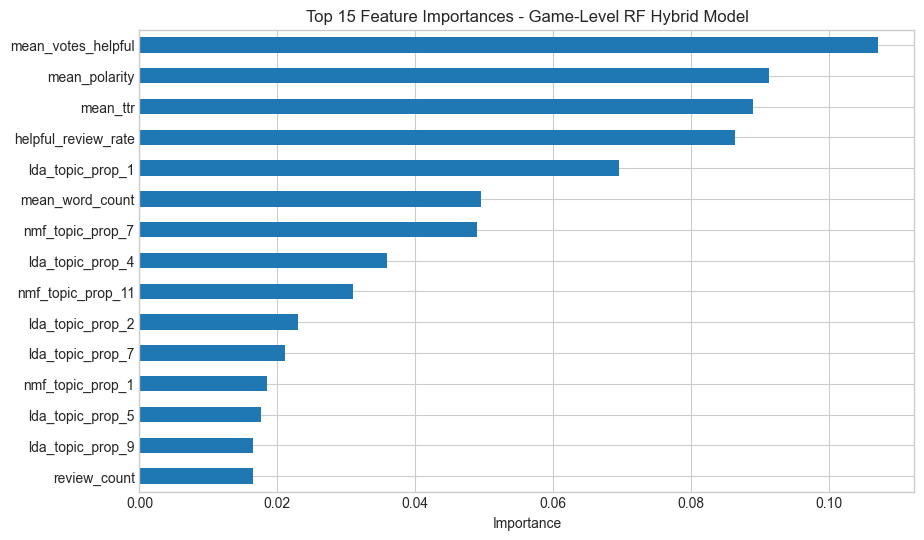

In [19]:
plt.figure(figsize=(10, 6))
rf_hybrid_importance.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances - Game-Level RF Hybrid Model")
plt.xlabel("Importance")
plt.show()

 Separate Behavioral and Text Contributions:

In addition to the overall importance ranking, I separate the most important variables into behavioral and text-based groups. This makes the interpretation clearer and helps show whether both branches are contributing useful information to the final game-level hybrid model.

In [20]:
behavioral_importance = rf_hybrid_importance[
    rf_hybrid_importance.index.isin(X_behavioral.columns)
].sort_values(ascending=False)

text_importance = rf_hybrid_importance[
    ~rf_hybrid_importance.index.isin(X_behavioral.columns)
].sort_values(ascending=False)

print("Top behavioral features:")
display(behavioral_importance.head(10))

print("\nTop text features:")
display(text_importance.head(10))

Top behavioral features:


mean_votes_helpful        0.107099
helpful_review_rate       0.086417
review_count              0.016427
received_for_free_rate    0.013398
steam_purchase_rate       0.010778
median_playtime_hours     0.010683
median_votes_helpful      0.009880
mean_playtime_hours       0.009445
mean_num_games_owned      0.008506
median_num_games_owned    0.008434
dtype: float64


Top text features:


mean_polarity        0.091374
mean_ttr             0.088950
lda_topic_prop_1     0.069544
mean_word_count      0.049547
nmf_topic_prop_7     0.048982
lda_topic_prop_4     0.035877
nmf_topic_prop_11    0.030937
lda_topic_prop_2     0.023019
lda_topic_prop_7     0.021163
nmf_topic_prop_1     0.018544
dtype: float64

Confusion Matrix for the Best Hybrid Model:

To complement the numerical metrics, I visualize the confusion matrix of the Adaboost hybrid model. This helps show how the game-level classifier is distributing correct and incorrect predictions across the two target classes.

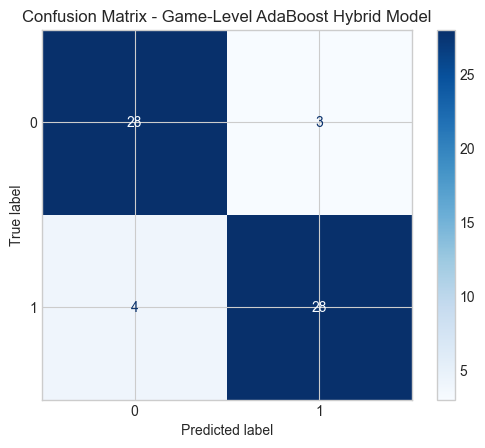

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_ada = ada_combined.predict(Xc_test_scaled)

cm = confusion_matrix(y_test, y_pred_ada)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Game-Level AdaBoost Hybrid Model")
plt.show()

ROC Curve Comparison for the Hybrid Models:

To make the evaluation more complete, I also compare the ROC curves of the three hybrid models:
- Logistic Regression Hybrid
- Random Forest Hybrid
- AdaBoost Hybrid

This provides a threshold-independent comparison and helps show which game-level hybrid model separates the two classes most effectively.

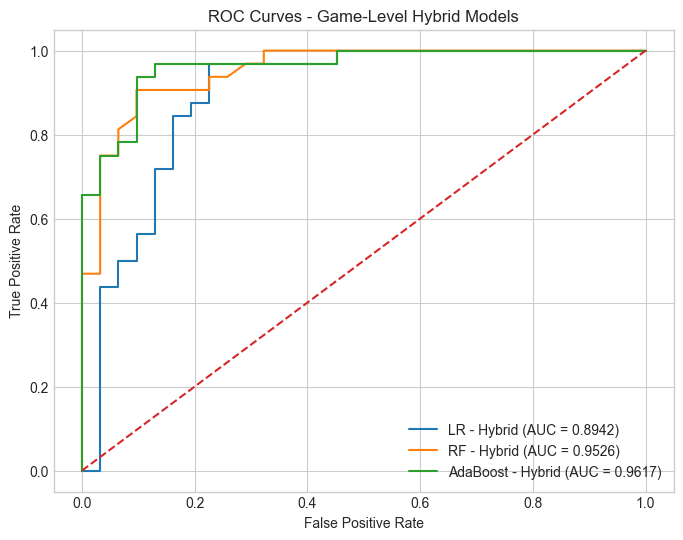

In [24]:
models_for_roc = {
    'LR - Hybrid': (lr_combined, Xc_test_scaled),
    'RF - Hybrid': (rf_combined, Xc_test),
    'AdaBoost - Hybrid': (ada_combined, Xc_test_scaled)
}

plt.figure(figsize=(8, 6))

for name, (model, X_data) in models_for_roc.items():
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Game-Level Hybrid Models")
plt.legend()
plt.show()

Final Conclusion:

The game-level hybrid experiment shows that aggregating behavioral and text-derived information to one row per game produces a strong and much more balanced classification setup than the earlier review-level task.

Among the tested models, AdaBoost Hybrid performed best overall. It achieved the strongest combination of:
- balanced class-wise precision, recall, and F1-score
- the cleanest confusion-matrix behavior across both classes
- the highest ROC-AUC among the hybrid models

This indicates that the game-level feature space is well suited to boosting-based classification. Unlike the review-level setting, where class imbalance made one class harder to predict, the game-level target was much more balanced because it was defined using the median recommendation rate. As a result, the final game-level models were able to separate both classes more consistently.

Overall, this notebook shows that:
- the full review-level data can be successfully aggregated to game level
- behavioral and text-derived features remain useful after aggregation
- adding game-level context, including topic proportions and optional cluster information, creates a strong hybrid representation
- AdaBoost Hybrid is the best final model for the game-level task

This makes the game-level notebook a useful extension of the earlier review-level hybrid analysis, showing that hybrid integration remains effective not only for individual reviews, but also for aggregated game-level prediction.